In [107]:
import src 
import matplotlib.pyplot as plt 
import astropy 
import pandas as pd 
import numpy as np 

# Automatically reload modules (so that it reloads when you edit the code)
%load_ext autoreload 
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Looking up '2002 NY40' in Simbad...
Simbad lookup failed (index 0 is out of bounds for axis 0 with size 0), trying JPL Horizons...


Retrieved '2002 NY40' from JPL Horizons
RA/dec calculated with cadence of 2h
Interpolating RA/dec onto 60min grid
Calculating altaz_frame
Calculating target altitudes on 60min grid
Interpolating target altitudes onto 5min grid
Calculating Sun altitudes on 60min grid
Interpolating Sun altitudes onto 5min grid
Looking up '2002 NY40' in Simbad...
Simbad lookup failed (index 0 is out of bounds for axis 0 with size 0), trying JPL Horizons...


Retrieved '2002 NY40' from JPL Horizons
RA/dec calculated with cadence of 5min
Interpolating RA/dec onto 5min grid
Calculating altaz_frame
Calculating target altitudes on 5min grid
Interpolating target altitudes onto 5min grid
Calculating Sun altitudes on 5min grid
Interpolating Sun altitudes onto 5min grid


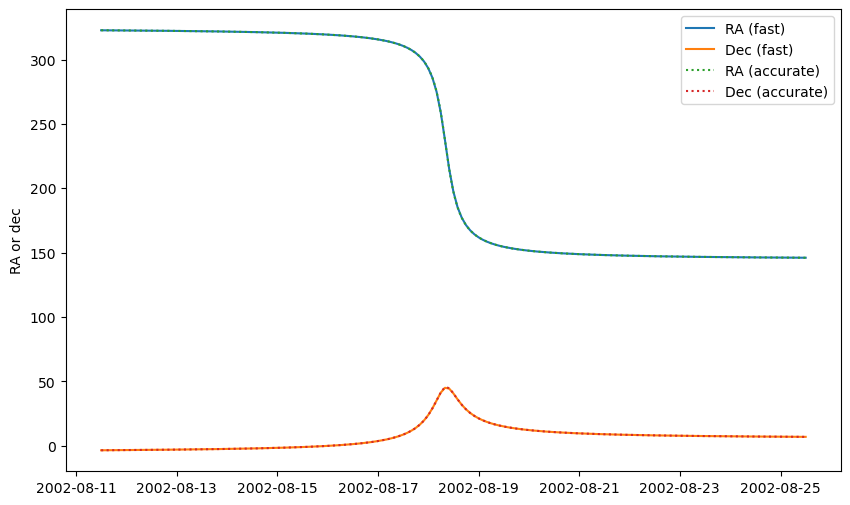

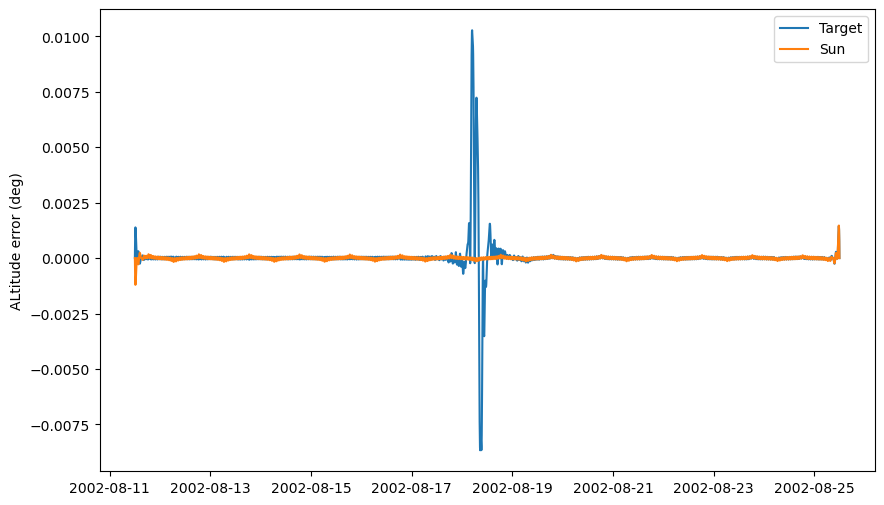

In [261]:

plt.figure(figsize=(10, 6)) 
plt.ylabel("RA or dec")



# Fast 
observer = src.get_observer(lat_long_tuple=(2, -100)) 
target = src.get_target(target_name="2002 NY40", num_days=14, start_str='2002-08-11 12:00:00', freq_calc_radec="2h")
dt_fast, targ_alt_fast, sun_alt_fast = src.calc_visibility(observer, target) 

plt.plot(target.times, target.ra, label="RA (fast)")
plt.plot(target.times, target.dec, label="Dec (fast)")

# Accurate 
observer = src.get_observer(lat_long_tuple=(2, -100)) 
target = src.get_target(target_name="2002 NY40", num_days=14, start_str='2002-08-11 12:00:00', freq_calc_radec="5min")
dt_acc, target_alt_acc, sun_alt_acc = src.calc_visibility(observer, target, freq_calc_altaz="5min", freq_interp_altaz="5min") 

plt.plot(target.times, target.ra, label="RA (accurate)", ls="dotted") 
plt.plot(target.times, target.dec, label="Dec (accurate)", ls="dotted") 

plt.legend() 



# Error plot 
plt.figure(figsize=(10, 6)) 
plt.plot(dt_acc, target_alt_acc-targ_alt_fast, label="Target")
plt.plot(dt_acc, sun_alt_acc-sun_alt_fast, label="Sun")
plt.ylabel("ALtitude error (deg)")
plt.legend() 

